In [2]:
import pandas as pd

# Load transactions dataset
df = pd.read_csv("../data/raw/transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000000, 7)


In [3]:
print(df.head())

   transaction_id      amount  country payment_method   device  hour  is_fraud
0               1  377.667418    Spain  bank_transfer   mobile    21         0
1               2  950.960735  Germany           card  desktop     3         0
2               3  733.333972    Spain  bank_transfer   tablet     4         0
3               4  600.665192    Italy           card   tablet     5         0
4               5  160.238547    Italy  bank_transfer  desktop     8         0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   transaction_id  1000000 non-null  int64  
 1   amount          1000000 non-null  float64
 2   country         1000000 non-null  str    
 3   payment_method  1000000 non-null  str    
 4   device          1000000 non-null  str    
 5   hour            1000000 non-null  int64  
 6   is_fraud        1000000 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 53.4 MB


In [5]:
df["is_fraud"].value_counts()

is_fraud
0    991270
1      8730
Name: count, dtype: int64

In [6]:
fraud_rate = df["is_fraud"].mean() * 100

print(f"Fraud rate: {fraud_rate:.2f}%")

Fraud rate: 0.87%


In [7]:
df["amount"].describe()

count    1000000.000000
mean         502.832814
std          287.148171
min            5.000516
25%          254.088510
50%          503.053194
75%          751.346244
max          999.998323
Name: amount, dtype: float64

In [8]:
df.groupby("is_fraud")["amount"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
is_fraud,,,,,
0,991270,501.613511,501.433276,5.000516,999.998323
1,8730,641.281647,761.455184,5.514141,999.940573


In [9]:
df.groupby("country")["is_fraud"].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)

,count,sum,mean
country,,,
Spain,200186,1810,0.009042
Germany,199705,1787,0.008948
France,200196,1757,0.008776
Morocco,199465,1714,0.008593
Italy,200448,1662,0.008291


In [10]:
df.groupby("payment_method")["is_fraud"].agg(
    ["count", "sum", "mean"]
).sort_values("mean", ascending=False)

,count,sum,mean
payment_method,,,
bank_transfer,333425,3957,0.011868
card,333092,2407,0.007226
paypal,333483,2366,0.007095


In [11]:
df.groupby("device")["is_fraud"].agg(["count", "sum", "mean"])

,count,sum,mean
device,,,
desktop,333993,2526,0.007563
mobile,332940,2585,0.007764
tablet,333067,3619,0.010866


In [12]:
df.groupby("hour")["is_fraud"].agg(["count", "sum", "mean"])

,count,sum,mean
hour,,,
0,41628,626,0.015038
1,41387,752,0.018170
2,41562,706,0.016987
3,41646,671,0.016112
4,41506,667,0.016070
5,41764,271,0.006489
6,41650,277,0.006651
7,41951,264,0.006293
8,41487,274,0.006604


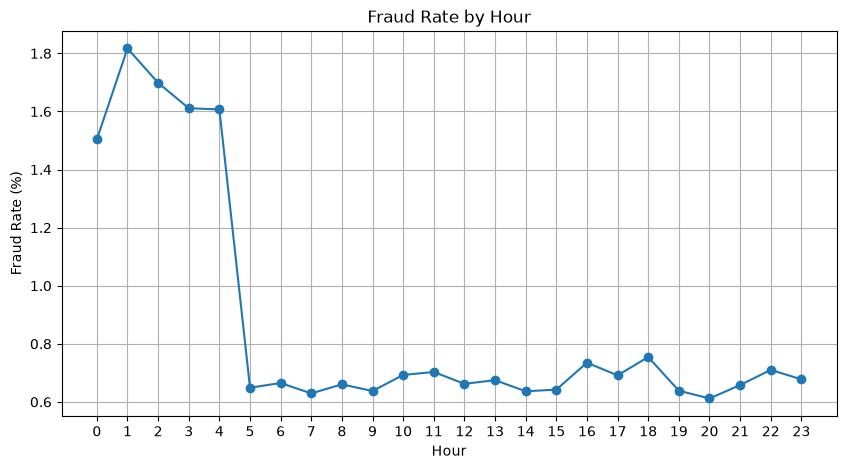

In [13]:
import matplotlib.pyplot as plt

fraud_by_hour = df.groupby("hour")["is_fraud"].mean()

plt.figure(figsize=(10, 5))
plt.plot(fraud_by_hour.index, fraud_by_hour.values * 100, marker="o")

plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [14]:
df.groupby("is_fraud")["amount"].agg(["count", "mean", "median", "max"])

,count,mean,median,max
is_fraud,,,,
0,991270,501.613511,501.433276,999.998323
1,8730,641.281647,761.455184,999.940573


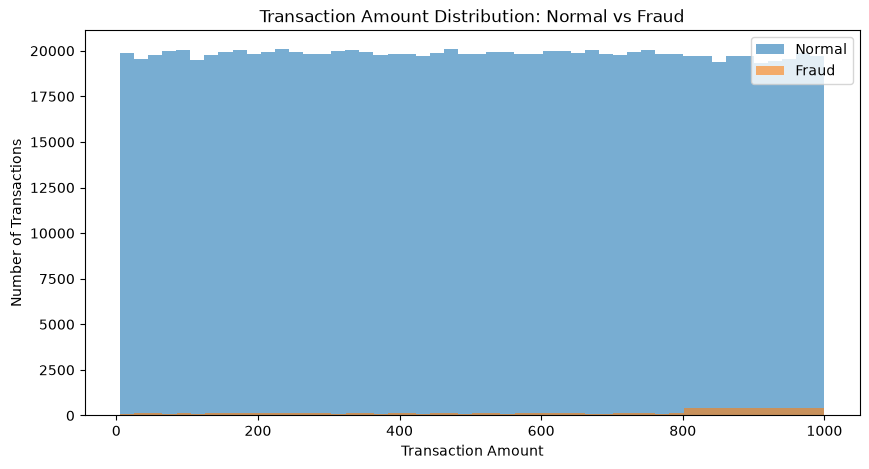

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["is_fraud"] == 0]["amount"],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df[df["is_fraud"] == 1]["amount"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution: Normal vs Fraud")
plt.legend()

plt.show()

In [16]:
df.isnull().sum()

transaction_id    0
amount            0
country           0
payment_method    0
device            0
hour              0
is_fraud          0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dtypes

transaction_id      int64
amount            float64
country               str
payment_method        str
device                str
hour                int64
is_fraud            int64
dtype: object

In [19]:
df["amount"].describe()

count    1000000.000000
mean         502.832814
std          287.148171
min            5.000516
25%          254.088510
50%          503.053194
75%          751.346244
max          999.998323
Name: amount, dtype: float64

In [20]:
df["country"].value_counts()

country
Italy      200448
France     200196
Spain      200186
Germany    199705
Morocco    199465
Name: count, dtype: int64

In [21]:
df["payment_method"].value_counts()

payment_method
paypal           333483
bank_transfer    333425
card             333092
Name: count, dtype: int64

In [22]:
df["device"].value_counts()

device
desktop    333993
tablet     333067
mobile     332940
Name: count, dtype: int64